**Enterprise Retail Analytics**

---
## Objective
Analyze retail sales data to understand revenue, profit drivers, customer behavior, and business performance.


##Step 1: Load Dataset
In this step, We load the Superstore dataset and check its basic structure.

In [3]:
#Load Dataset(latin1 used due to encoding issue)
import pandas as pd
df=pd.read_csv('/content/superstore.csv', encoding='latin1')
#Preview First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##Step 2:Dataset Size
we check the number of the rows and columns to understand the scale of the dataset.

In [4]:
#Check data shape
df.shape

(9994, 21)

##Step 3:Understanding the Data Structure
We examine column names to understand features available in the dataset

In [5]:
#View column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

##Step 4:Data Types and Information
we inspect data types and missing values to identify potential data quality issues

In [7]:
#Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Step 5: Initial Observations

- Dataset contains order, customer, product, and sales information  
- Key business metrics include Sales, Profit, Discount, and Quantity  
- Some columns may require cleaning (e.g., date formatting)

These observations will guide further data cleaning and analysis.

##Step 6: Checking missing values
We check for missing(null) values in the dataset to identify potential data quality issues.

In [8]:
#check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##Step 7: Checking Duplicate Records
we check for duplicate rows to ensure data accuracy.

In [9]:
#check duplicates
df.duplicated().sum()

np.int64(0)

##Step 8:Fixing Data Types
We convert date columns into proper datetime format for time based analysis.

In [10]:
#Convert date columns
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

##Step 9:Data Validation
We perform basic checks to ensure values are logical(eg. No negative sales)

In [11]:
#Check for negative sales or profit
df[df['Sales']<0]
df[df['Profit']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9920,9921,CA-2016-149272,2016-03-15,2016-03-19,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,77803,Central,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.3860,7,0.80,-35.8176
9921,9922,CA-2014-111360,2014-11-24,2014-11-30,Standard Class,AT-10435,Alyssa Tate,Home Office,United States,Akron,...,44312,East,OFF-BI-10003350,Office Supplies,Binders,Acco Expandable Hanging Binders,5.7420,3,0.70,-4.5936
9931,9932,CA-2015-104948,2015-11-13,2015-11-17,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,...,92404,West,FUR-BO-10004357,Furniture,Bookcases,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,4,0.15,-40.1960
9937,9938,CA-2016-164889,2016-06-03,2016-06-06,Second Class,CP-12340,Christine Phan,Corporate,United States,Los Angeles,...,90049,West,FUR-TA-10001676,Furniture,Tables,Hon 61000 Series Interactive Training Tables,71.0880,2,0.20,-1.7772


## Step 10: Data Cleaning Observations

- No missing values were found across the dataset, indicating good data completeness  
- No duplicate records detected, ensuring data consistency  
- Date columns were successfully converted into datetime format  

The dataset is clean and ready for further analysis.

##Step 11:Basic Business Metrics
we calculate total sales,total profit and total quantity to understand overall business performance.

In [18]:
#Total Sales
total_sales=round(df['Sales'].sum(),2)
total_sales


np.float64(2297200.86)

In [19]:
#Total Profit
total_profit=round(df['Profit'].sum(),2)
total_profit

np.float64(286397.02)

In [21]:
#Total Quantity
total_quantity=int(df['Quantity'].sum())
total_quantity

37873

## Step 12: Business Insights (Overall Performance)

- The total sales of the business is approximately 2.29 million  
- The total profit generated is around 286K  
- A total of 37,873 units were sold  

This indicates that while the business is generating strong revenue, further analysis is required to understand profit margins and identify areas for improvement.





##Step 13: Category Wise Analysis
We analyse sales and profit across product categories to identify which areas contribute most to the business.

In [24]:
#Categorising sales and profit
category_analysis= df.groupby('Category')[['Sales','Profit']].sum().sort_values(by ='Sales', ascending=False)
category_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


## Step 14: Category-wise Insights

- The Technology category generates the highest sales, contributing approximately **836K** in revenue  
- This indicates strong demand for technology products within the business  

However, high sales do not always translate to high profitability, so further analysis is required to evaluate profit contribution across categories.

##Step 15:Profit Analysis by category
we analyze profit across categories to understand which segments are most profitable.

In [26]:
#Profit Analysis
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


## Step 16: Category-wise Profit Insights

- The Technology category generates the highest profit, approximately **145K**, followed by Office Supplies and Furniture  
- This indicates that Technology products contribute the most to overall profitability  

- While Technology shows both high sales and high profit, further analysis is required to evaluate profit margins and identify if any sub-categories are underperforming  

- Furniture, despite having significant sales, appears to contribute less to profit, indicating potential inefficiencies such as high costs or excessive discounts  

##Sub-Category Analysis
We Analyse profit at the sub-category level to identify specific areas driving profit and loss.

In [28]:
subcat_profit=df.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


## Step 18: Sub-Category Insights

- The Tables sub-category is the worst-performing segment, generating a loss of approximately **-17.7K**, indicating significant profitability issues  

- The Copiers sub-category is the top-performing segment, contributing around **55.6K** in profit, making it a key driver of business profitability  

- A deeper look reveals that several products within the Furniture category are underperforming, particularly in terms of profit, despite contributing to overall sales  

- In contrast, Technology-related products consistently show strong performance in both sales and profitability  

These findings suggest that the business should focus on optimizing or reevaluating underperforming Furniture products while continuing to invest in high-performing Technology segments.

## Step 19: Discount Impact Analysis

We analyze the relationship between discount and profit to understand whether heavy discounting is negatively affecting profitability.

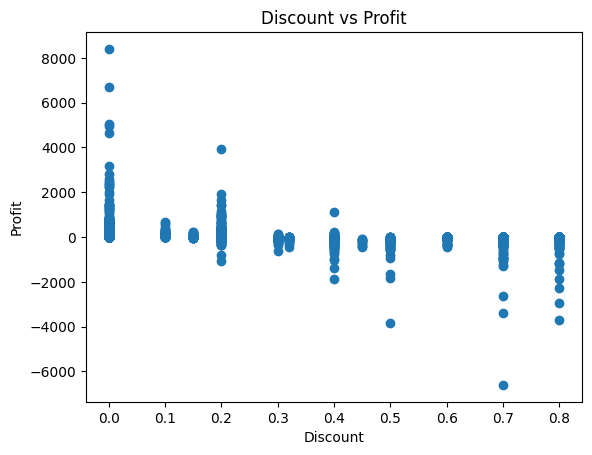

In [29]:
import matplotlib.pyplot as plt
plt.scatter(df['Discount'],df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

## Step 20: Discount Impact Insights

- The analysis shows a clear negative relationship between discount and profit, where higher discounts are associated with lower profitability  

- A significant number of transactions with high discounts result in negative profit, indicating that aggressive discounting is a key driver of losses  

- This pattern suggests that while discounts may help increase sales volume, they are adversely impacting overall profitability  

- The business should consider optimizing discount strategies, especially for low-margin or loss-making products, rather than uniformly reducing discounts across all categories  

## Step 21: Executive Summary

- The business generated approximately **2.29M in sales** and **286K in profit**, indicating strong overall performance  

- The Technology category is the primary driver of both sales and profit, while Furniture shows weaker profitability despite contributing to revenue  

- At the sub-category level, Tables are significantly loss-making, whereas Copiers are the most profitable segment  

- High discount levels are strongly associated with reduced profitability and are a major contributor to losses  

## Recommendations:

- Reevaluate pricing and discount strategies, especially for low-performing products such as Tables  
- Focus on high-performing segments like Technology and Copiers to maximize profitability  
- Implement controlled discounting strategies to balance sales growth and profit margins  